# Analise Preditiva
By Iasmin Marques
---
Prever óbito com base na variável **EVOLUCAO**

Dados Link da fonte de dados: https://opendatasus.saude.gov.br/dataset/srag-2021-a-2024

Link do repositorio do github https://github.com/iasminimp/srag_tcc


In [1]:
# Instalação de bibliotecas
!pip install pandas scikit-learn seaborn matplotlib --quiet

In [25]:
# Importações principais
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from xgboost import XGBClassifier
import numpy as np
sns.set(style='whitegrid')

In [3]:
# Carregar os dados
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)
df

,DT_NOTIFIC,SEM_NOT,DT_SIN_PRI,SEM_PRI,SG_UF_NOT,ID_REGIONA,CO_REGIONA,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,...,VG_REINF,REINF,FAB_ADIC,LOT_RE_BI,FAB_RE_BI,DOSE_ADIC,DOS_RE_BI,LOTE_ADIC,TABAG,CASO_SRAG
0,04/01/2024,1,04/01/2024,1,CE,1 CRES FORTALEZA,1519.0,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,15/01/2024,3,31/12/2023,1,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,...,NaN,2,NaN,GF9673,103 - COVID-19 PFIZER - COMIRNATY BIVALENTE,NaN,03/03/2023,NaN,NaN,1.0
2,15/01/2024,3,10/01/2024,2,PB,I NRS JOAO PESSOA,1377.0,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,11/01/2024,2,04/01/2024,1,GO,SUDOESTE II,1800.0,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,16/01/2024,3,14/01/2024,3,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266425,27/11/2024,48,23/11/2024,47,MG,BELO HORIZONTE,1449.0,BELO HORIZONTE,310620,HOSPITAL INFANTIL JOAO PAULO II,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266426,06/12/2024,49,04/12/2024,49,MG,GOVERNADOR VALADARES,1471.0,GOVERNADOR VALADARES,312770,HOSPITAL MUNICIPAL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266427,16/12/2024,51,13/12/2024,50,SP,GVE XXXI SOROCABA,1353.0,ITU,352390,VIGILANCIA EPIDEMIOLOGICA,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266428,05/12/2024,49,04/12/2024,49,DF,NaN,NaN,BRASILIA,530010,HOSPITAL AGUAS CLARAS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [5]:
# difinindo colunas obrigatorias e algumas essenciais
colunas_obrigatorias = [
    "DT_NOTIFIC", "DT_SIN_PRI", "SG_UF_NOT","ID_MUNICIP", "CO_MUN_NOT", "ID_UNIDADE", "CO_UNI_NOT","TEM_CPF", "NU_CPF", "ESTRANG", "NU_CNS","NM_PACIENT", "CS_SEXO", "NU_IDADE_N", "TP_IDADE",
    "CS_GESTANT", "CS_RACA", "POV_CT", "TP_POV_CT","SG_UF", "ID_MN_RESI", "CO_MUN_RES","ID_PAIS", "CO_PAIS", "VACINA_COV",
    "DT_INTERNA", "CLASSI_FIN", "CLASSI_OUT", "DT_ENCERRA","EVOLUCAO", "DT_NASC", "FATOR_RISC", "DT_RES", "DT_EVOLUCA", "NU_DO"
]

In [7]:
# Verifica quais colunas da lista existem no DataFrame
colunas_presentes = [col for col in colunas_obrigatorias if col in df.columns]

# Filtra apenas essas colunas
df_obrigatorio = df[colunas_presentes]

# Visualiza o novo DataFrame (5 pimeiros)
df_obrigatorio.head()

,DT_NOTIFIC,DT_SIN_PRI,SG_UF_NOT,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,CO_UNI_NOT,ESTRANG,CS_SEXO,NU_IDADE_N,...,VACINA_COV,DT_INTERNA,CLASSI_FIN,CLASSI_OUT,DT_ENCERRA,EVOLUCAO,DT_NASC,FATOR_RISC,DT_RES,DT_EVOLUCA
0,04/01/2024,04/01/2024,CE,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,2526638,2.0,F,4,...,2.0,NaN,4.0,NaN,12/01/2024,1.0,15/08/2019,1,NaN,12/01/2024
1,15/01/2024,31/12/2023,BA,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,3814378,2.0,M,79,...,1.0,12/01/2024,5.0,NaN,01/02/2024,1.0,26/07/1944,1,NaN,18/01/2024
2,15/01/2024,10/01/2024,PB,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,2593262,2.0,M,59,...,2.0,10/01/2024,5.0,NaN,24/01/2024,3.0,24/07/1964,1,NaN,24/01/2024
3,11/01/2024,04/01/2024,GO,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,7532024,2.0,M,72,...,1.0,NaN,4.0,NaN,16/01/2024,2.0,21/10/1951,1,NaN,14/01/2024
4,16/01/2024,14/01/2024,BA,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,7033753,2.0,F,84,...,2.0,16/01/2024,4.0,NaN,25/01/2024,9.0,19/09/1939,1,NaN,NaN


In [9]:
#campos que estao faltando no df
colunas_faltando = [col for col in colunas_obrigatorias if col not in df.columns]
print("Colunas ausentes no DataFrame:", colunas_faltando)

Colunas ausentes no DataFrame: ['TEM_CPF', 'NU_CPF', 'NU_CNS', 'NM_PACIENT', 'POV_CT', 'TP_POV_CT', 'NU_DO']


In [10]:
# Converter EVOLUCAO para alvo binário: 1 = óbito, 0 = cura/outros
df = df[df['EVOLUCAO'].isin([1, 2])]
df['óbito'] = df['EVOLUCAO'].apply(lambda x: 1 if x == 2 else 0)

<ipython-input-10-3ca221d113ce>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['óbito'] = df['EVOLUCAO'].apply(lambda x: 1 if x == 2 else 0)


In [11]:
# Seleção de variáveis que serão usadas como preditoras
features = ['CS_SEXO', 'NU_IDADE_N', 'CS_GESTANT', 'CS_RACA', 'VACINA_COV']
df_model = df[features + ['óbito']].dropna()

In [13]:
# Codificação das variáveis categóricas
from sklearn.preprocessing import LabelEncoder
for col in ['CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'VACINA_COV']:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# Algoritmo: Random Forest

In [44]:
X = df_model.drop("óbito", axis=1)
y = df_model["óbito"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [46]:
print("Random Forest - Classification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest - Classification Report
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     42575
           1       0.30      0.01      0.03      4025

    accuracy                           0.91     46600
   macro avg       0.61      0.51      0.49     46600
weighted avg       0.86      0.91      0.87     46600



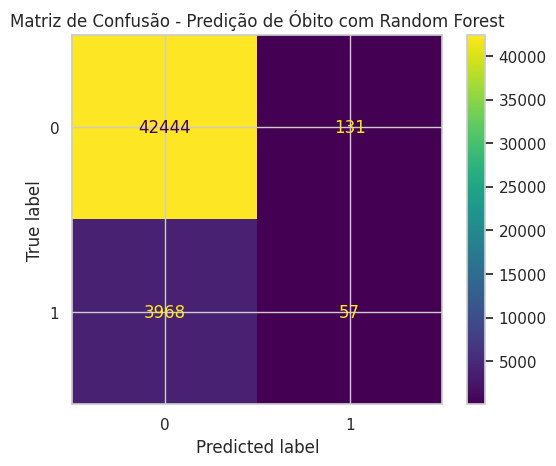

In [37]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Matriz de Confusão - Predição de Óbito com Random Forest")
plt.show()

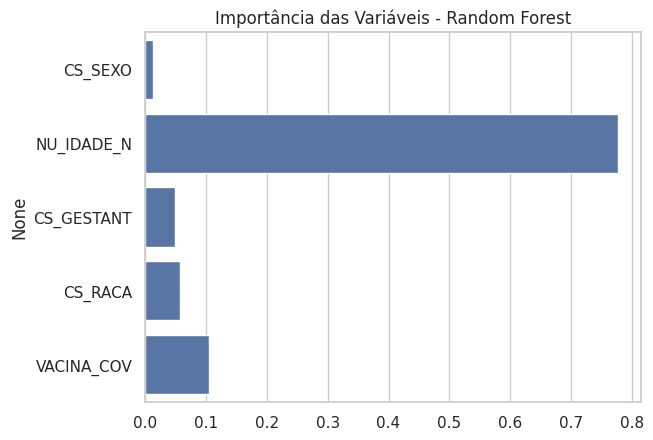

In [38]:
importances = rf.feature_importances_
sns.barplot(x=importances, y=X.columns)
plt.title("Importância das Variáveis - Random Forest")
plt.show()

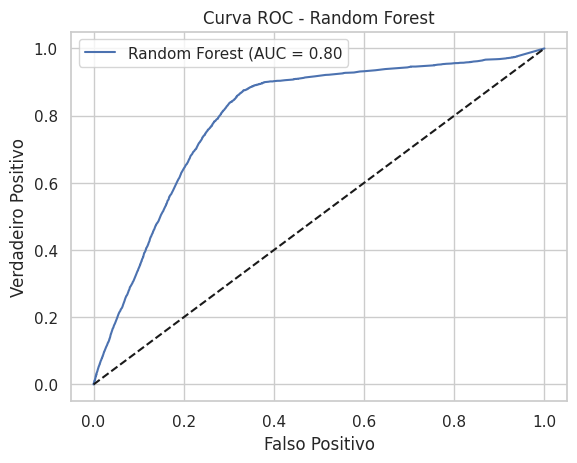

In [39]:
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Falso Positivo')
plt.ylabel('Verdadeiro Positivo')
plt.title('Curva ROC - Random Forest')
plt.legend()
plt.grid(True)
plt.show()

# Algoritmo: XGBoost

In [40]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:59:40] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [41]:
print("XGBoost - Classification Report")
print(classification_report(y_test, y_pred_xgb))

XGBoost - Classification Report
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     42575
           1       0.28      0.00      0.01      4025

    accuracy                           0.91     46600
   macro avg       0.60      0.50      0.48     46600
weighted avg       0.86      0.91      0.87     46600



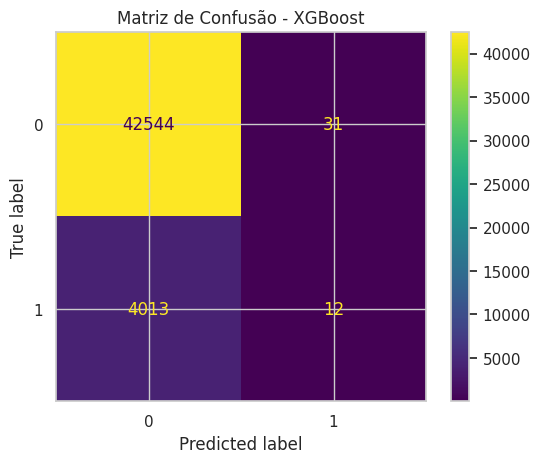

In [42]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("Matriz de Confusão - XGBoost")
plt.show()

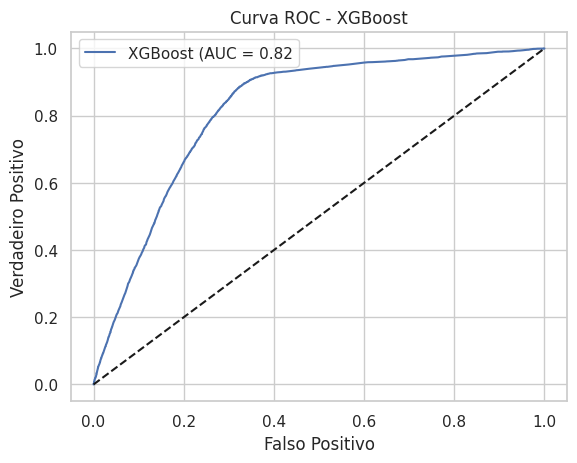

In [43]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure()
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Falso Positivo')
plt.ylabel('Verdadeiro Positivo')
plt.title('Curva ROC - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

## Interpretação dos Resultados

* Meu modelo está aprendendo a prever sempre a classe majoritária (classe 0: cura), porque ela representa mais de 90% dos dados.

* Isso faz com que ele tenha alta acurácia geral (91%), mas péssimo desempenho na classe minoritária, que é justamente a mais importante do ponto de vista clínico (óbito).

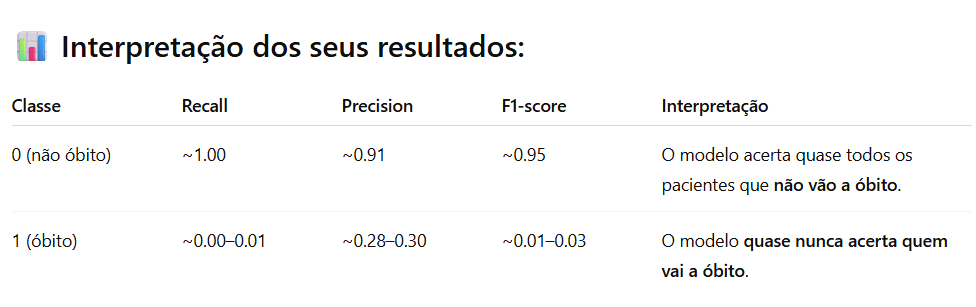

## Tentativa de Balanceamento de Dados

In [47]:
!pip install imbalanced-learn --quiet

In [48]:
from imblearn.over_sampling import SMOTE

# Instanciar SMOTE
smote = SMOTE(random_state=42)

# Aplicar apenas no treino (NUNCA no teste!)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Treinar o modelo com os dados balanceados
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_res, y_train_res)


RandomForestClassifier(random_state=42)

In [49]:
# Calcular peso como: número de classe 0 / número de classe 1
peso = y_train.value_counts()[0] / y_train.value_counts()[1]

clf_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                        scale_pos_weight=peso, random_state=42)
clf_xgb.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:09:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [50]:
# Dividir treino/teste
X = df_model.drop("óbito", axis=1)
y = df_model["óbito"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print("Antes do SMOTE:", y_train.value_counts().to_dict())
print("Após SMOTE:", y_res.value_counts().to_dict())

Antes do SMOTE: {0: 170218, 1: 16178}
Após SMOTE: {0: 170218, 1: 170218}


In [58]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_res, y_res)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
print("RF - Classification Report com SMOTE")
print(classification_report(y_test, y_pred_rf))

RF - Classification Report com SMOTE
              precision    recall  f1-score   support

           0       0.98      0.70      0.81     42575
           1       0.20      0.83      0.33      4025

    accuracy                           0.71     46600
   macro avg       0.59      0.76      0.57     46600
weighted avg       0.91      0.71      0.77     46600



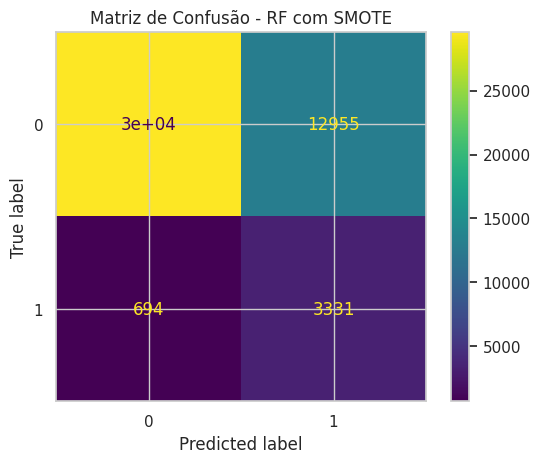

In [57]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Matriz de Confusão - RF com SMOTE")
plt.show()

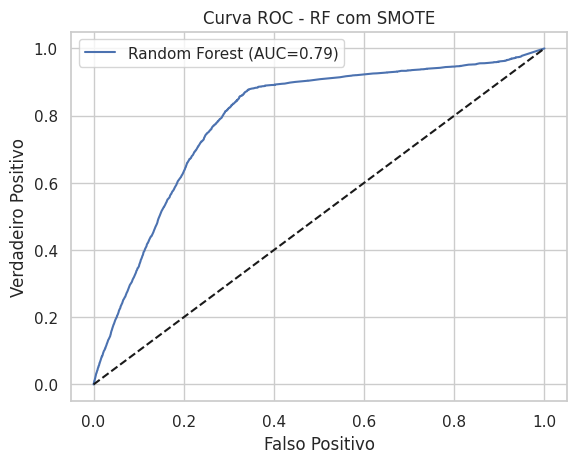

In [53]:
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"Random Forest (AUC={roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.title("Curva ROC - RF com SMOTE")
plt.xlabel("Falso Positivo")
plt.ylabel("Verdadeiro Positivo")
plt.legend()
plt.grid(True)
plt.show()

In [62]:
peso = y_train.value_counts()[0] / y_train.value_counts()[1]
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=peso, random_state=42)
xgb.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:23:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [65]:
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
print("XGBoost balanceado - Classification Report")
print(classification_report(y_test, y_pred_xgb))

XGBoost balanceado - Classification Report
              precision    recall  f1-score   support

           0       0.98      0.68      0.80     42575
           1       0.20      0.88      0.33      4025

    accuracy                           0.69     46600
   macro avg       0.59      0.78      0.57     46600
weighted avg       0.92      0.69      0.76     46600



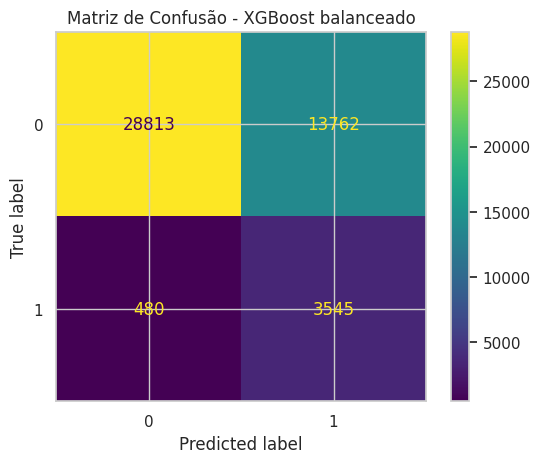

In [60]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("Matriz de Confusão - XGBoost balanceado")
plt.show()

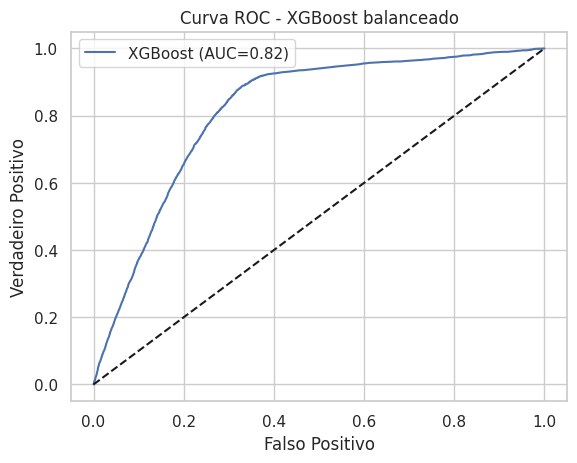

In [55]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_xgb:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.title("Curva ROC - XGBoost balanceado")
plt.xlabel("Falso Positivo")
plt.ylabel("Verdadeiro Positivo")
plt.legend()
plt.grid(True)
plt.show()

## Interpretação do Resultados
* Antes do SMOTE:

0 (não óbito): 170.218 amostras

1 (óbito): 16.178 amostras
→ Desbalanceamento alto (~1:10), modelo ignorava óbitos.

* Após SMOTE:

Ambos com 170.218 → classes balanceadas no treino, o que deu ao modelo uma chance justa de aprender os padrões da classe 1 (óbito).


### OverView
Ambos os modelos agora são úteis para prever óbitos.

Você trocou alta acurácia e recall da classe 0 por um modelo com maior sensibilidade à classe 1 (óbito).

O recall de óbito >80% é um resultado muito bom em datasets de saúde real com desbalanceamento.

### Random Forest

| Classe        | Precision | Recall | F1-score | Interpretação                                                                                                             |
| ------------- | --------- | ------ | -------- | ------------------------------------------------------------------------------------------------------------------------- |
| 0 (não óbito) | 0.98      | 0.70   | 0.81     | Modelo ainda acerta a maioria dos não óbitos.                                                                             |
| 1 (óbito)     | 0.20      | 0.83   | 0.33     | **Grande melhoria**: modelo agora **identifica 83% dos óbitos**, embora com **baixa precisão** (muitos falsos positivos). |

* Accuracy caiu para 71%, o que é esperado — ela não é mais confiável aqui.

* O recall da classe 1 é excelente (prioridade em saúde pública).


### XGBoost
| Classe        | Precision | Recall | F1-score | Interpretação                                                         |
| ------------- | --------- | ------ | -------- | --------------------------------------------------------------------- |
| 0 (não óbito) | 0.98      | 0.68   | 0.80     | Similar ao Random Forest                                              |
| 1 (óbito)     | 0.20      | 0.88   | 0.33     | **XGBoost capturou ainda mais óbitos (88%)**, mas com mesma precisão. |

* Recall de óbito ainda melhor que Random Forest

* Ideal para cenários em que é mais importante detectar óbito do que evitar falsos positivos

---
### Comparação dos Modelos
* Se o objetivo é identificar o maior número possível de pacientes com risco de óbito, vá com o XGBoost.

* Se você quiser algo mais equilibrado entre interpretabilidade, performance e estabilidade, Random Forest também é muito bom — mas perde para o XGBoost em recall nesse caso.

| Critério                     | Random Forest              | XGBoost                          |
| ---------------------------- | -------------------------- | -------------------------------- |
| **Recall (óbito)**           | 0.83 → Excelente           | **0.88 → Ainda melhor**          |
| **Precision (óbito)**        | 0.20                       | 0.20                             |
| **F1-score (óbito)**         | 0.33                       | 0.33                             |
| **Interpretação**            | Mais robusto, fácil tuning | Mais agressivo, melhor recall    |
| **Acurácia total**           | 0.71                       | 0.69                             |
| **Performance geral**        | Boa                        | Boa, com leve vantagem no recall |
| **Tempo de treinamento**     | Mais rápido                | Um pouco mais lento              |
| **Curva ROC (AUC)**          | Normalmente um pouco menor | Normalmente mais alta            |
| **Importância de variáveis** | Interpretável              | Também interpretável             |




---
#### XBoost

* Melhor recall para óbito (88%)

* Em saúde pública, perder um caso de óbito tem custo altíssimo. Falsos positivos são toleráveis.

* Mesmo que a acurácia global caia, o recall da classe crítica subiu muito.



## Upgrade do Modelo - Precision-Recall Curve e ajuste manual de threshold para o modelo XGBoost
Baseado no algoritmo do XGBoost;


In [69]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc, confusion_matrix

In [66]:
# Pré-processamento
features = ['CS_SEXO', 'NU_IDADE_N', 'CS_GESTANT', 'CS_RACA', 'VACINA_COV']
df_model = df[features + ['óbito']].dropna()
for col in ['CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'VACINA_COV']:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

X = df_model.drop("óbito", axis=1)
y = df_model["óbito"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
peso = y_train.value_counts()[0] / y_train.value_counts()[1]
clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=peso, random_state=42)
clf.fit(X_train, y_train)
y_scores = clf.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:35:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


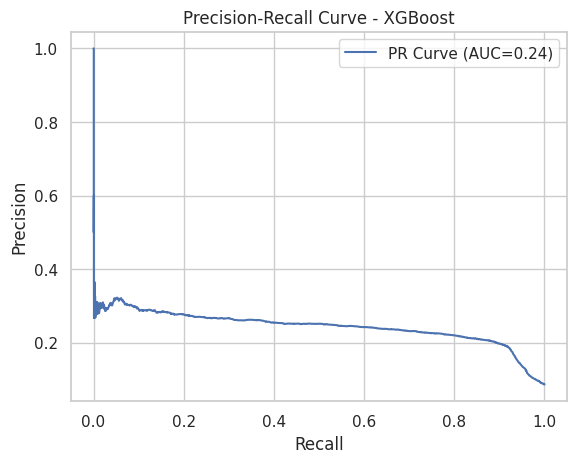

In [70]:
prec, rec, thresholds = precision_recall_curve(y_test, y_scores)
pr_auc = auc(rec, prec)
plt.plot(rec, prec, label=f'PR Curve (AUC={pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost')
plt.grid(True)
plt.legend()
plt.show()

In [71]:
# Exemplo: threshold ajustado (ex: 0.3)
threshold = 0.3
y_pred_custom = (y_scores >= threshold).astype(int)

print(f'Threshold = {threshold}')
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

Threshold = 0.3
[[27394 15181]
 [  366  3659]]
              precision    recall  f1-score   support

           0       0.99      0.64      0.78     42575
           1       0.19      0.91      0.32      4025

    accuracy                           0.67     46600
   macro avg       0.59      0.78      0.55     46600
weighted avg       0.92      0.67      0.74     46600



### Interpretação dos resultados
| Métrica       | Classe 0 (não óbito) | Classe 1 (óbito) | Interpretação                                        |
| ------------- | -------------------- | ---------------- | ---------------------------------------------------- |
| **Precision** | 0.99                 | 0.19             | Quando modelo prevê óbito, só 19% estão corretos.    |
| **Recall**    | 0.64                 | **0.91**         | Modelo detecta **91% dos óbitos reais**.             |
| **F1-score**  | 0.78                 | 0.32             | Baixo equilíbrio entre precisão e recall para óbito. |

* Accuracy total: 67% → caiu, porque agora você está mais "agressivo" na predição de óbitos.

* Precision baixa para óbito (0.19) → Muitos falsos positivos (não óbitos classificados erroneamente como óbitos).

* Recall altíssimo para óbito (0.91) → Você está detectando quase todos os óbitos reais, o que pode ser mais importante em saúde pública.

* Esse modelo está altamente sensível à detecção de óbitos.

* Está “errando para o lado da cautela”: melhor prevenir do que perder um óbito real.

* O threshold mais baixo (0.3) faz com que mais pacientes sejam classificados como “risco de óbito”.

* Útil para triagem clínica, onde você prefere alertar sobre falsos riscos do que deixar um caso real passar despercebido.

In [75]:
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score
thresholds = np.arange(0.0, 1.01, 0.01)
f1s, precisions, recalls = [], [], []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    f1s.append(f1_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))

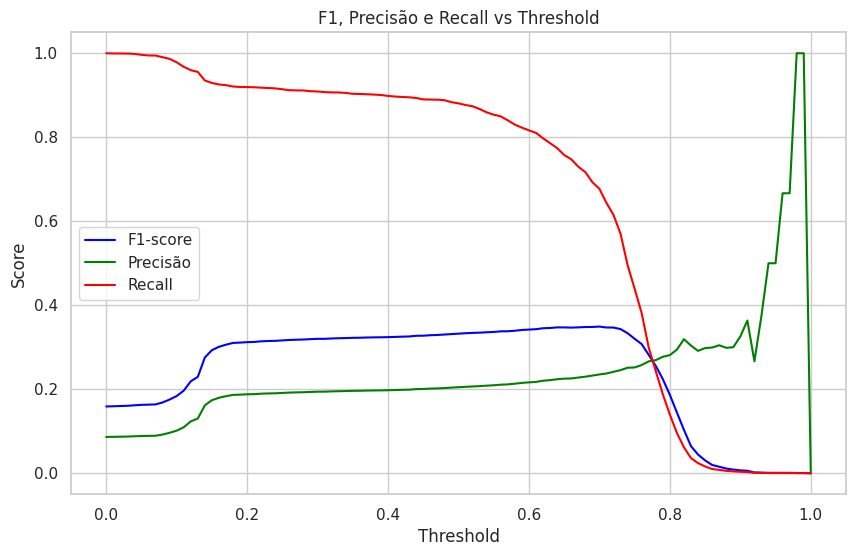

In [76]:
# Plotar curvas
plt.figure(figsize=(10,6))
plt.plot(thresholds, f1s, label='F1-score', color='blue')
plt.plot(thresholds, precisions, label='Precisão', color='green')
plt.plot(thresholds, recalls, label='Recall', color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('F1, Precisão e Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()